# Lane Detection using OpenCV
##### Based on https://github.com/d-misra/Lane-detection-opencv-python

Modification made to fit the indoor setting of the geicar:
- Hough lines thereshold and min line length
- Mask to extract the black color of a picture
- Modification of the Hough-line averaging with pick_lane_lines to filter the raw Hough detection
- Modification to have utility functions reusable in the geicar architecture


## Part 1 : Modifying the code and test in a gei

In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Canny edge detection + Remove irrelevant segments of the image and retain only the lane portion
def canny_edges_with_roi(binary_mask, canny_low=50, canny_high=150, roi_vertical_ratio=0.55):
    edges = cv2.Canny(binary_mask, canny_low, canny_high)
    h, w = edges.shape[:2]
    roi_mask = np.zeros_like(edges)
    cv2.rectangle(roi_mask,(0, int(h * roi_vertical_ratio)),(w, h),255,-1)
    return cv2.bitwise_and(edges, roi_mask)



# Function modified to YCrCb
def dark_tape_mask(
    bgr_image,
    lower_ycrcb=np.array([0,   100,  100]),  # Param to Adapt
    upper_ycrcb=np.array([110, 140, 140]),    # Param to Adapt
    kernel_size=5
):
    # BGR -> YCrCb
    ycrcb = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2YCrCb)

    # Threshold for dark, low‑chroma pixels (black-ish)
    mask = cv2.inRange(ycrcb, lower_ycrcb, upper_ycrcb)

    # Morphological filtering to keep thick blobs and remove noise
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=1)

    return mask


# Hough segments
def hough_lines(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=15,       
    min_line_length=80,     # Parameter to adapt
    max_line_gap=30         # Parameter to adapt
):
    return cv2.HoughLinesP(
        edges,
        rho=rho,
        theta=theta,
        threshold=threshold,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )


def pick_lane_lines(image_shape, lines,
                    min_angle_deg=3,   
                    max_angle_deg=85,
                    k_longest=8,
                    min_length=20):   #Value to modify  
    if lines is None:
        return None

    h, w = image_shape[:2]
    x_center = w / 2.0
    min_angle = np.deg2rad(min_angle_deg)
    max_angle = np.deg2rad(max_angle_deg)

    segs = []
    for l in lines:
        x1, y1, x2, y2 = l.reshape(4)
        dx, dy = x2 - x1, y2 - y1
        length = np.hypot(dx, dy)
        if length < min_length:
            continue
        angle = np.arctan2(dy, dx)
        aabs = abs(angle)
        if aabs < min_angle or aabs > max_angle:
            continue

        xm = 0.5 * (x1 + x2)
        side = 'L' if xm < x_center else 'R'
        segs.append({'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                     'length': length, 'angle': angle,
                     'xm': xm, 'side': side})

    if len(segs) == 0:
        return None

    left  = sorted([s for s in segs if s['side']=='L'],
                   key=lambda s: -s['length'])[:k_longest]
    right = sorted([s for s in segs if s['side']=='R'],
                   key=lambda s: -s['length'])[:k_longest]

    def avg_side(group):
        arr = np.array([[g['x1'], g['y1'], g['x2'], g['y2']] for g in group],
                       dtype=float)
        return arr.mean(axis=0).astype(int)

    lanes = []

    if left and right:
        # Geometry scoring to pick one best (L,R) pair
        y_ref = 0.75 * h
        best_pair, best_score = None, -1e9

        def x_at_y(seg, y):
            x1, y1, x2, y2 = seg['x1'], seg['y1'], seg['x2'], seg['y2']
            if y2 == y1:
                return (x1 + x2) / 2.0
            return x1 + (y - y1) * (x2 - x1) / (y2 - y1)

        for L in left:
            for R in right:
                # Parallelism
                dang = abs(L['angle'] - R['angle'])
                dang = min(dang, np.pi - dang)
                score_parallel = -dang

                # Width near bottom
                x_left= x_at_y(L, y_ref)
                x_right = x_at_y(R, y_ref)
                width = x_right -x_left
                if width <= 40 or width >= 0.9 * w:
                    continue

                # Centering
                lane_center = (x_left+ x_right) / 2.0
                off_center = abs(lane_center - x_center)
                score_center = -off_center / w

                # Length
                score_len = (L['length'] + R['length']) / (h + w)

                score = 3.0*score_parallel + 2.0*score_len + 1.0*score_center
                if score > best_score:
                    best_score = score
                    best_pair = (L, R)

        if best_pair is not None:
            L, R = best_pair
            lanes.append(avg_side([L]))
            lanes.append(avg_side([R]))

        else:
            # best single segment overall
            best_single = max(segs, key=lambda s: s['length'])
            lanes.append(avg_side([best_single]))

    elif left and not right:
        lanes.append(avg_side(left))   # only left lane

    elif right and not left:
        lanes.append(avg_side(right))  # only right lane

    return np.array(lanes) if lanes else None


def detect_lanes_dark_tape(input_image, draw_fn, thickness=8, debug=False):
    # 1) Color segmentation of black thick tape
    mask = dark_tape_mask(input_image)

    # 2) Canny only on tape (via ROI function so you can tune later)
    edges = canny_edges_with_roi(mask)

    edges = cv2.dilate(edges, np.ones((3,3), np.uint8), iterations=1)

    # 3) Hough + lane selection
    lines = hough_lines(edges)
    lane_lines = pick_lane_lines(input_image.shape, lines)

    # 4) Draw result
    output = draw_fn(input_image, lane_lines, thickness=thickness)

    if debug:
        plt.figure(figsize=(10,4))
        plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)); plt.title("Input"); plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Tape mask"); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow(edges, cmap='gray'); plt.title("Edges on tape"); plt.axis('off')
        plt.show()

    return output, lane_lines, edges, mask


# Draws lines of given thickness over an image
def draw_lines(image, lines, thickness):
    if lines is None:
        return image

    line_image = np.zeros_like(image)
    if len(line_image.shape) == 2:
        line_image = cv2.cvtColor(line_image, cv2.COLOR_GRAY2BGR)

    color = (0, 0, 255)
    for x1, y1, x2, y2 in lines:
        cv2.line(line_image, (x1, y1), (x2, y2), color, thickness)

    combined_image = cv2.addWeighted(image, 0.8, line_image, 1.0, 0.0)
    return combined_image


#### Section with the set of images for testing parameter

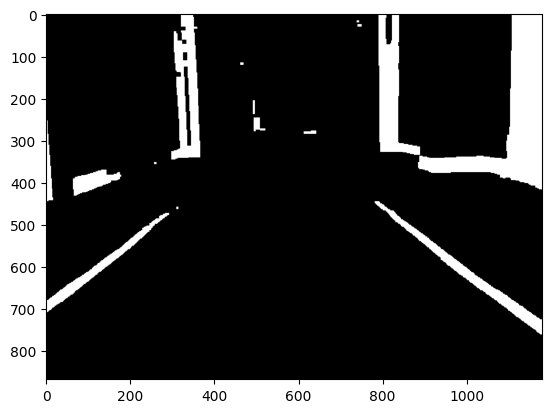

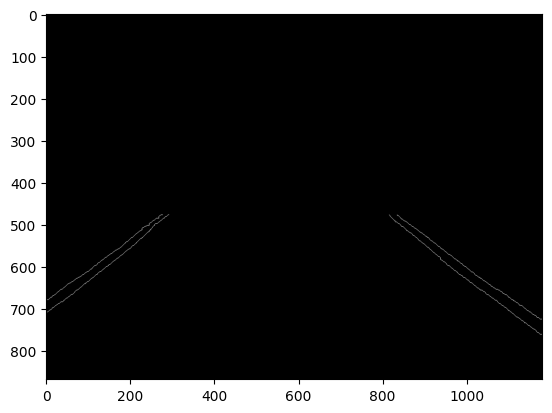

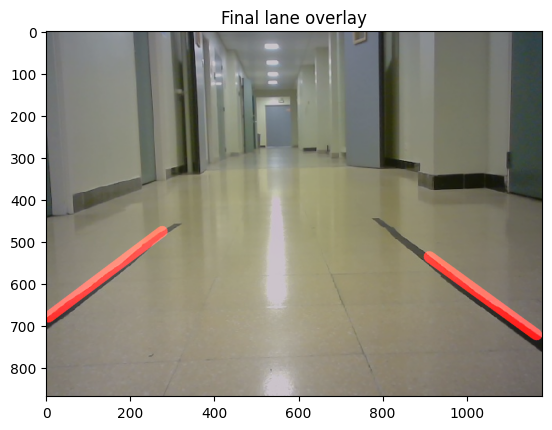

In [12]:
# Image Test 1
inputimage = cv2.imread("test_demo.png")

# ou recommandé : RGB -> YCrCb
ycrcb = cv2.cvtColor(inputimage, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)


plt.figure()
plt.imshow(cv2.cvtColor(inputimage, cv2.COLOR_BGR2RGB))

# Change the inputimage
masked_input = dark_tape_mask(inputimage)
plt.imshow(cv2.cvtColor(masked_input, cv2.COLOR_BGR2RGB))
# Canny edge detection + Remove irrelevant segments of the image and retain only the lane portion
 
edges = canny_edges_with_roi(masked_input)
plt.figure()
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.show()

output, lanes, edges, mask = detect_lanes_dark_tape(
    inputimage,
    draw_fn=draw_lines,
    thickness=25
)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Final lane overlay")
plt.show()


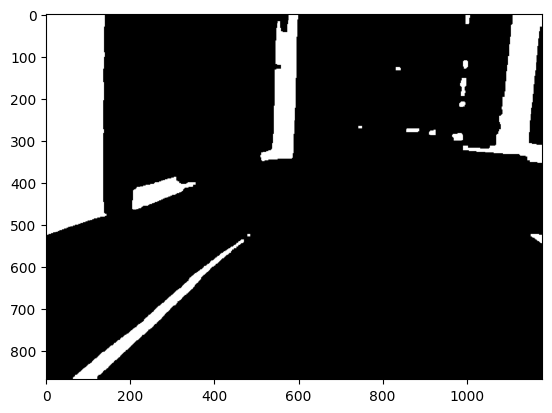

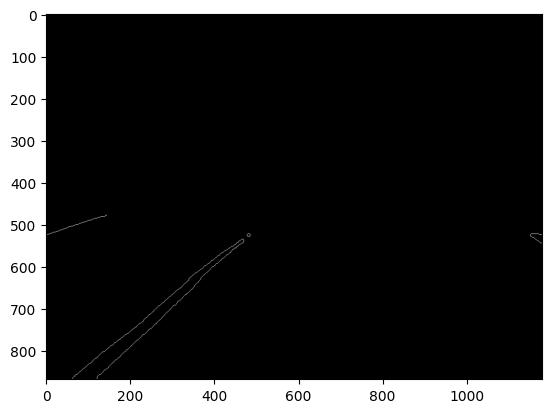

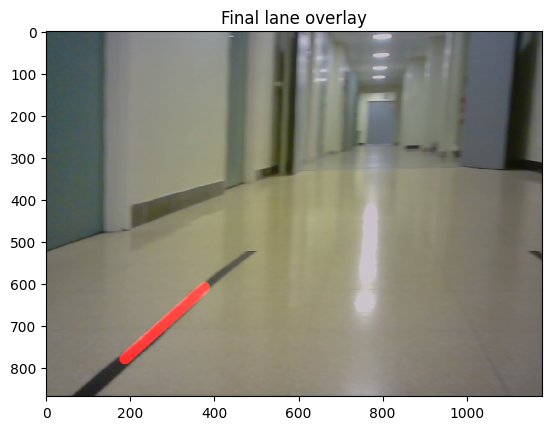

In [13]:
# Image Test 2
inputimage = cv2.imread("test_demo2.png")

# ou recommandé : RGB -> YCrCb
ycrcb = cv2.cvtColor(inputimage, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)


plt.figure()
plt.imshow(cv2.cvtColor(inputimage, cv2.COLOR_BGR2RGB))

# Change the inputimage
masked_input = dark_tape_mask(inputimage)
plt.imshow(cv2.cvtColor(masked_input, cv2.COLOR_BGR2RGB))
# Canny edge detection + Remove irrelevant segments of the image and retain only the lane portion
 
edges = canny_edges_with_roi(masked_input)
plt.figure()
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.show()

output, lanes, edges, mask = detect_lanes_dark_tape(
    inputimage,
    draw_fn=draw_lines,
    thickness=25
)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Final lane overlay")
plt.show()


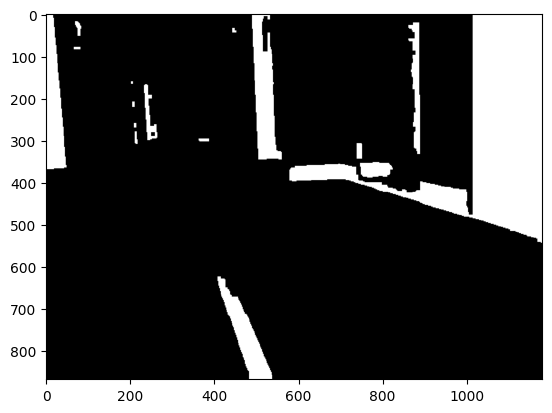

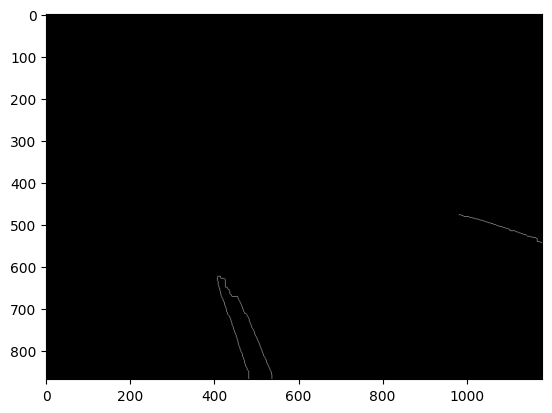

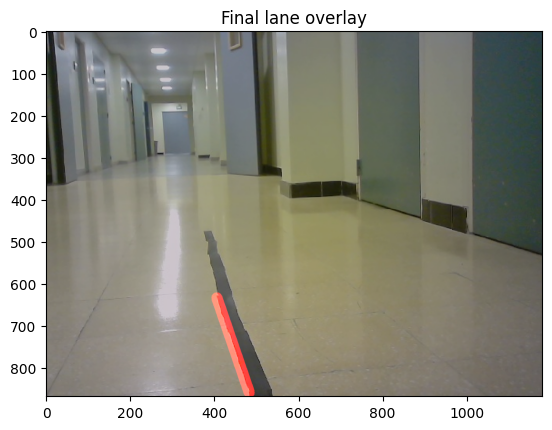

In [14]:
# Image Test 3
inputimage = cv2.imread("test_demo3.png")

# ou recommandé : RGB -> YCrCb
ycrcb = cv2.cvtColor(inputimage, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)


plt.figure()
plt.imshow(cv2.cvtColor(inputimage, cv2.COLOR_BGR2RGB))

# Change the inputimage
masked_input = dark_tape_mask(inputimage)
plt.imshow(cv2.cvtColor(masked_input, cv2.COLOR_BGR2RGB))
# Canny edge detection + Remove irrelevant segments of the image and retain only the lane portion
 
edges = canny_edges_with_roi(masked_input)
plt.figure()
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.show()

output, lanes, edges, mask = detect_lanes_dark_tape(
    inputimage,
    draw_fn=draw_lines,
    thickness=25
)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Final lane overlay")
plt.show()


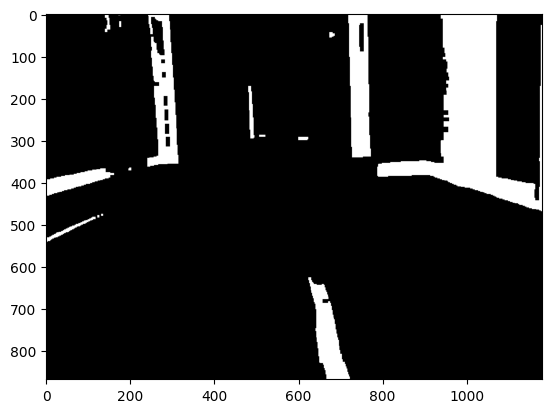

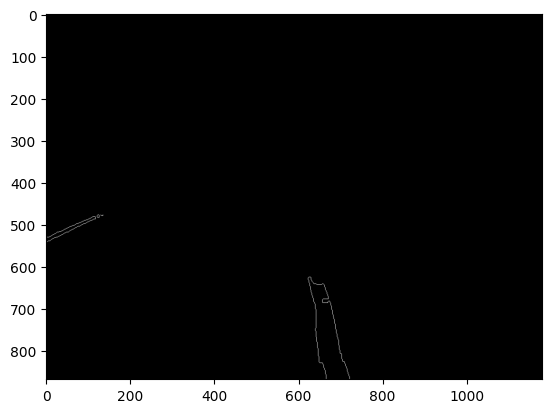

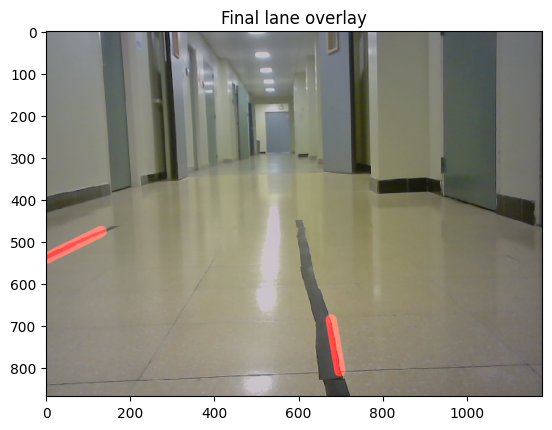

In [15]:
# Image Test 4
inputimage = cv2.imread("test_demo4.png")

# ou recommandé : RGB -> YCrCb
ycrcb = cv2.cvtColor(inputimage, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)


plt.figure()
plt.imshow(cv2.cvtColor(inputimage, cv2.COLOR_BGR2RGB))

# Change the inputimage
masked_input = dark_tape_mask(inputimage)
plt.imshow(cv2.cvtColor(masked_input, cv2.COLOR_BGR2RGB))
# Canny edge detection + Remove irrelevant segments of the image and retain only the lane portion
 
edges = canny_edges_with_roi(masked_input)
plt.figure()
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.show()

output, lanes, edges, mask = detect_lanes_dark_tape(
    inputimage,
    draw_fn=draw_lines,
    thickness=25
)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Final lane overlay")
plt.show()


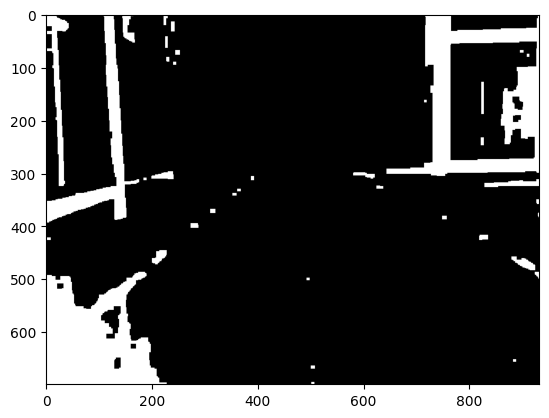

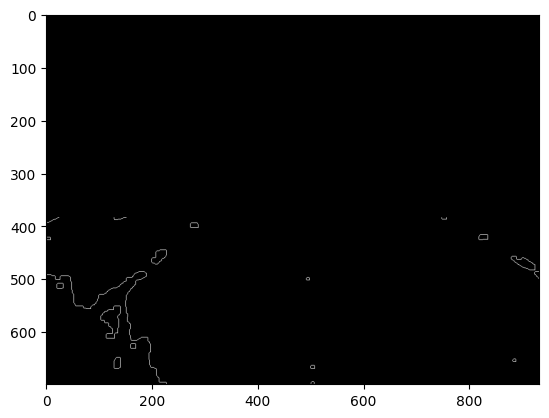

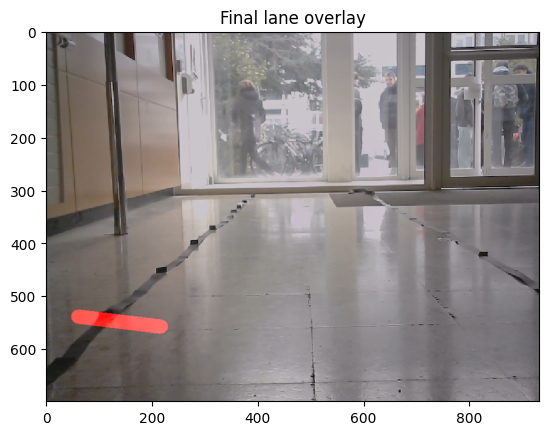

In [16]:
# Image Test 5
inputimage = cv2.imread("test5.png")

# ou recommandé : RGB -> YCrCb
ycrcb = cv2.cvtColor(inputimage, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)


plt.figure()
plt.imshow(cv2.cvtColor(inputimage, cv2.COLOR_BGR2RGB))

# Change the inputimage
masked_input = dark_tape_mask(inputimage)
plt.imshow(cv2.cvtColor(masked_input, cv2.COLOR_BGR2RGB))
# Canny edge detection + Remove irrelevant segments of the image and retain only the lane portion
 
edges = canny_edges_with_roi(masked_input)
plt.figure()
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.show()

output, lanes, edges, mask = detect_lanes_dark_tape(
    inputimage,
    draw_fn=draw_lines,
    thickness=25
)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Final lane overlay")
plt.show()


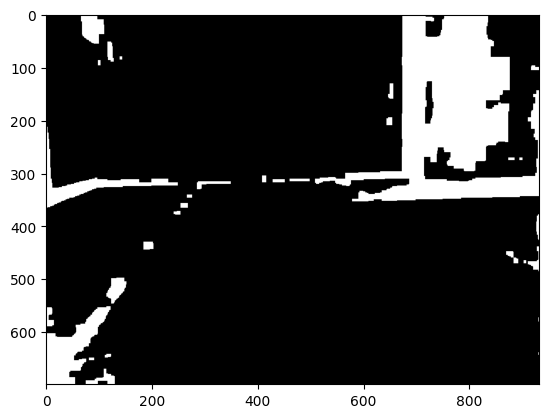

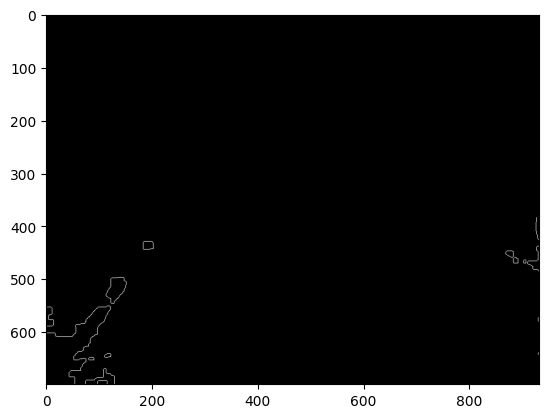

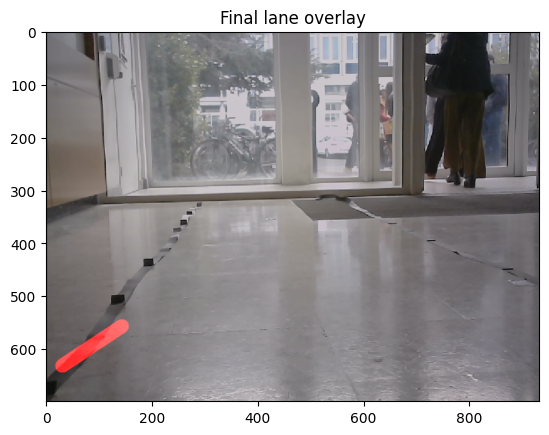

In [17]:
# Image Test 6
inputimage = cv2.imread("test6.png")

# ou recommandé : RGB -> YCrCb
ycrcb = cv2.cvtColor(inputimage, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)


plt.figure()
plt.imshow(cv2.cvtColor(inputimage, cv2.COLOR_BGR2RGB))

# Change the inputimage
masked_input = dark_tape_mask(inputimage)
plt.imshow(cv2.cvtColor(masked_input, cv2.COLOR_BGR2RGB))
# Canny edge detection + Remove irrelevant segments of the image and retain only the lane portion
 
edges = canny_edges_with_roi(masked_input)
plt.figure()
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.show()

output, lanes, edges, mask = detect_lanes_dark_tape(
    inputimage,
    draw_fn=draw_lines,
    thickness=25
)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Final lane overlay")
plt.show()


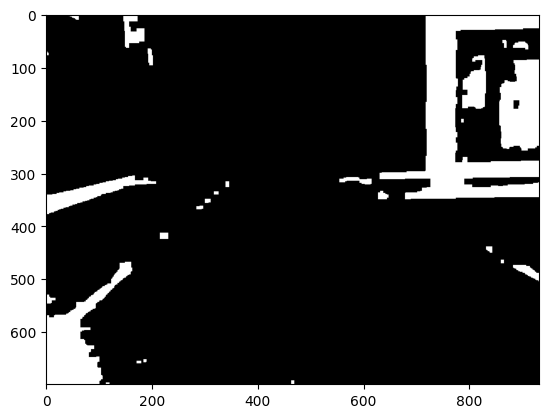

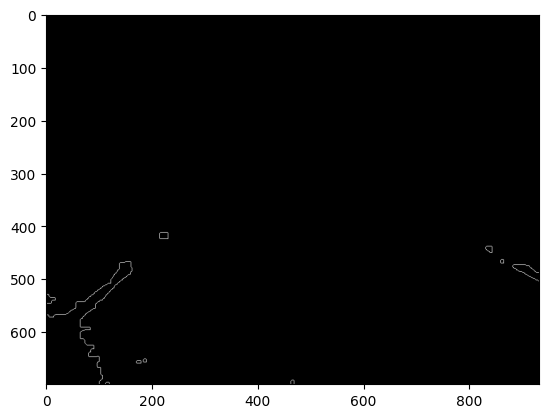

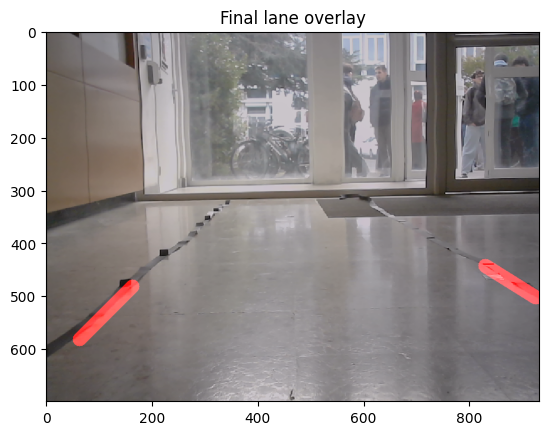

In [18]:
# Image Test 7
inputimage = cv2.imread("test7.png")

# ou recommandé : RGB -> YCrCb
ycrcb = cv2.cvtColor(inputimage, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)


plt.figure()
plt.imshow(cv2.cvtColor(inputimage, cv2.COLOR_BGR2RGB))

# Change the inputimage
masked_input = dark_tape_mask(inputimage)
plt.imshow(cv2.cvtColor(masked_input, cv2.COLOR_BGR2RGB))
# Canny edge detection + Remove irrelevant segments of the image and retain only the lane portion
 
edges = canny_edges_with_roi(masked_input)
plt.figure()
plt.imshow(cv2.cvtColor(edges, cv2.COLOR_BGR2RGB))
plt.show()

output, lanes, edges, mask = detect_lanes_dark_tape(
    inputimage,
    draw_fn=draw_lines,
    thickness=25
)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Final lane overlay")
plt.show()
